# LightGBM

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import lightgbm as lgb
from lightgbm import log_evaluation
import time
import re
import joblib
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import warnings
warnings.filterwarnings('ignore')
# Download NLTK data
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
print(f"LightGBM version: {lgb.__version__}")

LightGBM version: 4.6.0


back to root to call functions from helpers.py file

In [2]:
import os
from pathlib import Path
print(Path.cwd())
os.chdir(Path('..').resolve())
from src.utils.helpers import save
print(Path.cwd())

/mnt/d/career/digilians/sentiment-analysis-of-amazon-reviews-using-machine-learning/notebooks
/mnt/d/career/digilians/sentiment-analysis-of-amazon-reviews-using-machine-learning


## Data Acquisition

load dataset

In [3]:
X_train_tfidf = sp.load_npz('data/vectorizers/X_train_tfidf.npz').tocsr()
print(f"X_train shape: {X_train_tfidf.shape}")
y_train = pd.read_csv('data/processed/y_train.csv').squeeze()
print(f"y_train shape: {y_train.shape}")

X_train shape: (79972, 100000)
y_train shape: (79972,)


In [4]:
X_valid = sp.load_npz('data/vectorizers/X_valid_tfidf.npz').tocsr()
print(f"X_valid shape: {X_valid.shape}")
y_valid = pd.read_csv('data/processed/y_valid.csv').squeeze()
print(f"y_valid shape: {y_valid.shape}")

X_valid shape: (20000, 100000)
y_valid shape: (20000,)


In [5]:
X_test_tfidf = sp.load_npz('data/vectorizers/X_test_tfidf.npz').tocsr()
print(f"X_test shape: {X_test_tfidf.shape}")
y_test = pd.read_csv('data/processed/y_test.csv').squeeze()
print(f"y_test shape: {y_test.shape}")

X_test shape: (20000, 100000)
y_test shape: (20000,)


In [6]:
# Convert sparse matrices to dense for XGBoost
X_train_dense = X_train_tfidf.tocsr().astype(np.float32)
# Use sparse CSR float32 to avoid dense allocation (LightGBM accepts sparse matrices)
X_test_dense = X_test_tfidf.tocsr().astype(np.float32)
# Convert [1, 2] labels to [0, 1]
y_train = y_train.astype(int) - 1
y_test = y_test.astype(int) - 1

## 5: LightGBM Model Training

In [7]:
# Train LightGBM Classifier
print("Training LightGBM Classifier...")
start_time = time.time()
lgb_classifier = lgb.LGBMClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    num_leaves=31,
    min_child_samples=20,
    reg_alpha=0,
    reg_lambda=1,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
    metric='binary_logloss'
)
lgb_classifier.fit(
    X_train_dense, y_train,
    eval_set=[(X_test_dense, y_test)], # Optional: for logging
    callbacks=[log_evaluation(period=0)] # Equivalent to verbose=False
)
training_time = time.time() - start_time
print(f"Training completed in {training_time:.4f} seconds")

Training LightGBM Classifier...


Training completed in 117.6661 seconds


## 6: Model Evaluation

In [8]:
# Make predictions
y_pred = lgb_classifier.predict(X_test_dense)
# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
# Print results
print("LIGHTGBM CLASSIFIER - PERFORMANCE METRICS")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"Training Time: {training_time:.4f} seconds")

LIGHTGBM CLASSIFIER - PERFORMANCE METRICS
Accuracy:  0.8312
Precision: 0.8202
Recall:    0.8497
F1-Score:  0.8347
Training Time: 117.6661 seconds


## 7: Classification Report

In [9]:
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

Classification Report:
              precision    recall  f1-score   support

    Negative       0.84      0.81      0.83      9966
    Positive       0.82      0.85      0.83     10034

    accuracy                           0.83     20000
   macro avg       0.83      0.83      0.83     20000
weighted avg       0.83      0.83      0.83     20000



## 8: Confusion Matrix Visualization

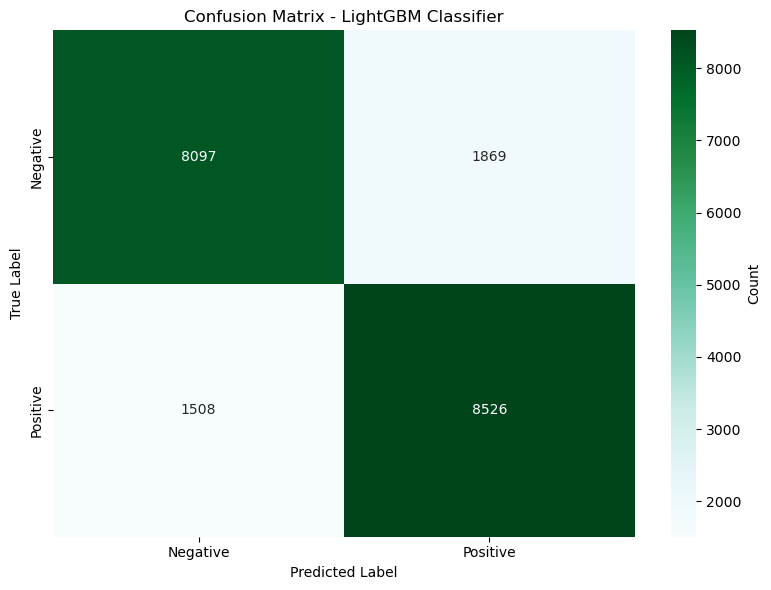

Confusion Matrix:
[[8097 1869]
 [1508 8526]]

True Negatives: 8097
False Positives: 1869
False Negatives: 1508
True Positives: 8526


In [10]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='BuGn',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - LightGBM Classifier')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('lightgbm_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Confusion Matrix:\n{cm}")
print(f"\nTrue Negatives: {cm[0,0]}")
print(f"False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}")
print(f"True Positives: {cm[1,1]}")

## 9: Feature Importance

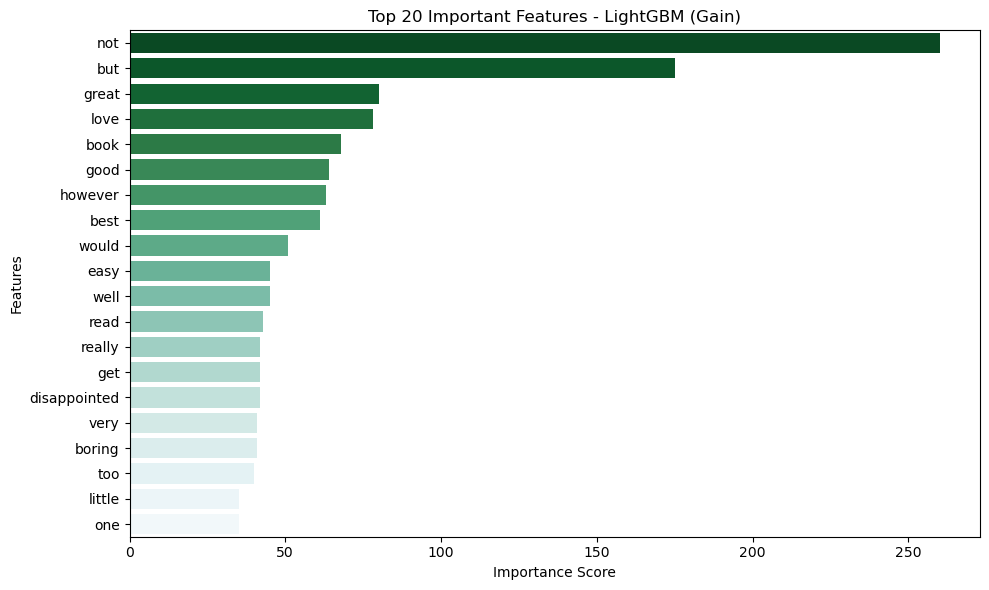


Top 20 Important Features:
     feature  importance
         not         260
         but         175
       great          80
        love          78
        book          68
        good          64
     however          63
        best          61
       would          51
        easy          45
        well          45
        read          43
      really          42
         get          42
disappointed          42
        very          41
      boring          41
         too          40
      little          35
         one          35


In [11]:
# Get feature importance
tfidf_vectorizer = joblib.load('data/vectorizers/tfidf_vectorizer.joblib')
feature_names = tfidf_vectorizer.get_feature_names_out()
importances = lgb_classifier.feature_importances_
# Create DataFrame for better visualization
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False).head(20)
# Plot top features
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='importance', y='feature', palette='BuGn_r')
plt.title('Top 20 Important Features - LightGBM (Gain)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.savefig('lightgbm_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print("\nTop 20 Important Features:")
print(importance_df.to_string(index=False))

## 10: Feature Importance by Type

In [12]:
# Get feature importance by split (how many times feature is used for splitting)
split_importance = lgb_classifier.booster_.feature_importance(importance_type='split')
# Create DataFrame
split_df = pd.DataFrame({
    'feature': feature_names,
    'split_count': split_importance
}).sort_values('split_count', ascending=False).head(10)
print("Top 10 Features by Split Count (How often used for splitting):")
print(split_df.to_string(index=False))

Top 10 Features by Split Count (How often used for splitting):
feature  split_count
    not          260
    but          175
  great           80
   love           78
   book           68
   good           64
however           63
   best           61
  would           51
   easy           45


## 11: Model Summary

In [13]:
print("LIGHTGBM MODEL SUMMARY")
print(f"\nModel Parameters:")
print(f"  - Number of Estimators: {lgb_classifier.n_estimators}")
print(f"  - Max Depth: {lgb_classifier.max_depth}")
print(f"  - Learning Rate: {lgb_classifier.learning_rate}")
print(f"  - Num Leaves: {lgb_classifier.num_leaves}")
print(f"  - Min Child Samples: {lgb_classifier.min_child_samples}")
print(f"  - Subsample: {lgb_classifier.subsample}")
print(f"  - Colsample by Tree: {lgb_classifier.colsample_bytree}")
print(f"\nFeature Engineering:")
print(f"  - Vectorizer: TF-IDF")
print(f"  - Max Features: 5000")
print(f"  - N-gram Range: (1, 2)")
print(f"  - Min Document Frequency: 5")
print(f"  - Max Document Frequency: 0.8")
print(f"\nPerformance:")
print(f"  - Accuracy:  {accuracy:.4f}")
print(f"  - Precision: {precision:.4f}")
print(f"  - Recall:    {recall:.4f}")
print(f"  - F1-Score:  {f1:.4f}")
print(f"  - Training Time: {training_time:.4f} seconds")
print(f"\nModel Characteristics:")
print(f"  - Boosting Type: gbdt (Gradient Boosting Decision Tree)")
print(f"  - Tree Learner: serial")
print(f"  - Objective: binary_logloss")
print(f"  - Speed Advantage: Fastest among tree-based models")

LIGHTGBM MODEL SUMMARY

Model Parameters:
  - Number of Estimators: 200
  - Max Depth: 6
  - Learning Rate: 0.1
  - Num Leaves: 31
  - Min Child Samples: 20
  - Subsample: 0.8
  - Colsample by Tree: 0.8

Feature Engineering:
  - Vectorizer: TF-IDF
  - Max Features: 5000
  - N-gram Range: (1, 2)
  - Min Document Frequency: 5
  - Max Document Frequency: 0.8

Performance:
  - Accuracy:  0.8312
  - Precision: 0.8202
  - Recall:    0.8497
  - F1-Score:  0.8347
  - Training Time: 117.6661 seconds

Model Characteristics:
  - Boosting Type: gbdt (Gradient Boosting Decision Tree)
  - Tree Learner: serial
  - Objective: binary_logloss
  - Speed Advantage: Fastest among tree-based models


## Saving the Model and Pipeline

In [14]:
save(model_base='data/models', model=lgb_classifier, model_name='13_lightgbm_classifier.joblib')

Saved model 13_lightgbm_classifier.joblib to data/models/13_lightgbm_classifier.joblib


{'model': PosixPath('data/models/13_lightgbm_classifier.joblib')}